In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
print("All imports successful.")


All imports successful.


## Task 1 – Mall Customer Segmentation


### 1.1 · Load Dataset


In [39]:
df_mall = pd.read_csv('Mall_Customers.csv')

print(f"Shape: {df_mall.shape}")
print(f"Columns: {list(df_mall.columns)}")
df_mall.head()


Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1.2 · Explore & Encode

In [40]:
df_mall.columns = [c.strip() for c in df_mall.columns]
rename_map = {}
for c in df_mall.columns:
    cl = c.lower()
    if 'income' in cl:                    rename_map[c] = 'Annual_Income'
    elif 'spending' in cl:                rename_map[c] = 'Spending_Score'
    elif 'genre' in cl or 'gender' in cl: rename_map[c] = 'Gender'
    elif 'age' in cl:                     rename_map[c] = 'Age'
    elif 'id' in cl:                      rename_map[c] = 'CustomerID'
df_mall.rename(columns=rename_map, inplace=True)

le_mall = LabelEncoder()
df_mall['Gender_enc'] = le_mall.fit_transform(df_mall['Gender'])

print(f"Missing values: {df_mall.isnull().sum().sum()}")
print(f"Gender encoding: {dict(zip(le_mall.classes_, le_mall.transform(le_mall.classes_)))}")
df_mall.describe()


Missing values: 0
Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


,CustomerID,Age,Annual_Income,Spending_Score,Gender_enc
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,0.440000
std,57.879185,13.969007,26.264721,25.823522,0.497633
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,0.000000
75%,150.250000,49.000000,78.000000,73.000000,1.000000
max,200.000000,70.000000,137.000000,99.000000,1.000000


### 1.3 · Elbow Method

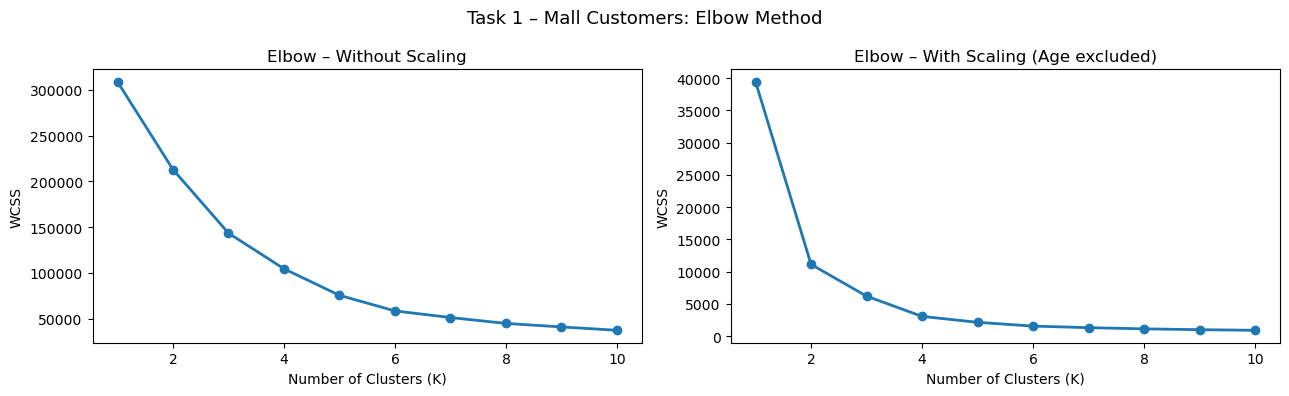

Pick the K at the sharpest elbow bend above, then set OPTIMAL_K in the next cell.


In [41]:
all_feats   = ['Gender_enc', 'Age', 'Annual_Income', 'Spending_Score']
scale_feats = ['Gender_enc', 'Annual_Income', 'Spending_Score']

X_raw = df_mall[all_feats].values
sc_mall = StandardScaler()
X_sc_part = sc_mall.fit_transform(df_mall[scale_feats])
X_sc = np.hstack([df_mall[['Age']].values, X_sc_part])

K_range = range(1, 11)
wcss_raw, wcss_sc = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    wcss_raw.append(km.fit(X_raw).inertia_)
    wcss_sc.append(km.fit(X_sc).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, wcss, title in zip(
    axes, [wcss_raw, wcss_sc],
    ['Without Scaling', 'With Scaling (Age excluded)']
):
    ax.plot(K_range, wcss, marker='o', linewidth=2)
    ax.set_title(f'Elbow – {title}')
    ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('WCSS')

fig.suptitle('Task 1 – Mall Customers: Elbow Method', fontsize=13)
plt.tight_layout(); plt.show()
print("Pick the K at the sharpest elbow bend above, then set OPTIMAL_K in the next cell.")


### 1.4 · Cluster Without Scaling

In [42]:
OPTIMAL_K = 5

km_raw = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df_mall['Cluster_NoScale'] = km_raw.fit_predict(X_raw)

print(f"=== WITHOUT Scaling (K={OPTIMAL_K}) ===")
print(df_mall.groupby('Cluster_NoScale')[all_feats].mean().round(2))


=== WITHOUT Scaling (K=5) ===
                 Gender_enc    Age  Annual_Income  Spending_Score
Cluster_NoScale                                                  
0                      0.39  45.22          26.30           20.91
1                      0.42  43.09          55.29           49.57
2                      0.46  32.69          86.54           82.13
3                      0.53  40.67          87.75           17.58
4                      0.39  25.52          26.30           78.57


### 1.5 · Cluster With Scaling (Age excluded)

In [43]:
km_sc = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df_mall['Cluster_Scaled'] = km_sc.fit_predict(X_sc)

print(f"=== WITH Scaling, Age excluded (K={OPTIMAL_K}) ===")
print(df_mall.groupby('Cluster_Scaled')[all_feats].mean().round(2))


=== WITH Scaling, Age excluded (K=5) ===
                Gender_enc    Age  Annual_Income  Spending_Score
Cluster_Scaled                                                  
0                     0.64  63.54          52.79           38.50
1                     0.39  30.00          71.17           67.30
2                     0.33  49.19          59.86           35.65
3                     0.47  21.16          45.68           54.95
4                     0.44  37.60          67.78           49.89


### 1.6 · Visualise & Compare

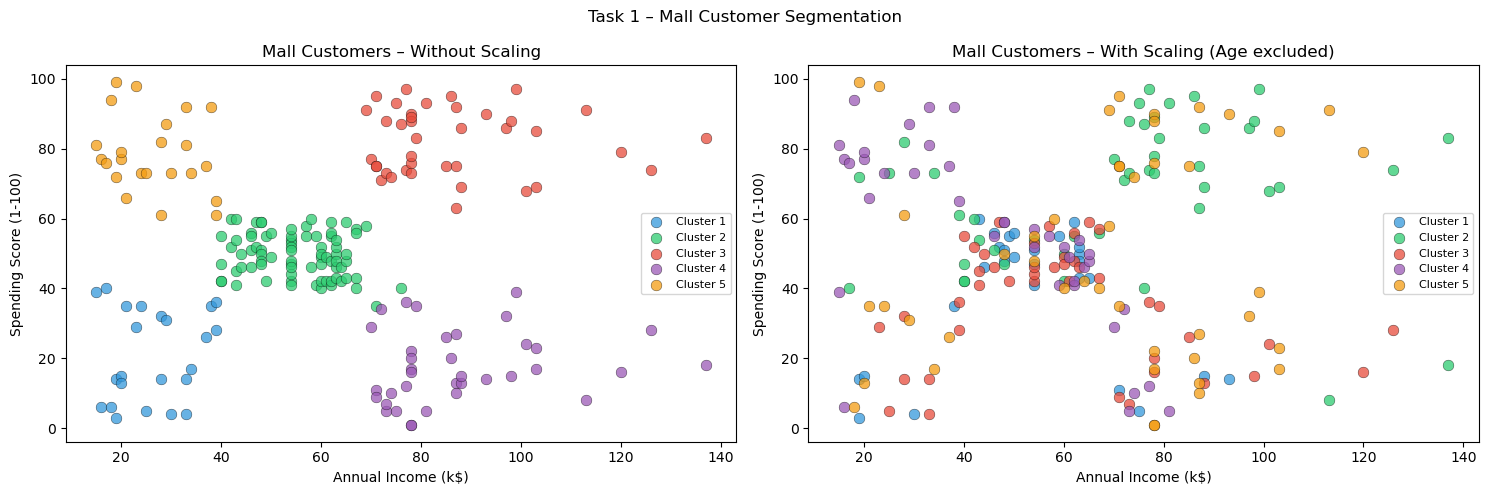

In [44]:
colors_k = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12',
            '#1abc9c','#e67e22','#34495e']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ['Cluster_NoScale', 'Cluster_Scaled'],
    ['Without Scaling', 'With Scaling (Age excluded)']
):
    for c in range(OPTIMAL_K):
        mask = df_mall[col] == c
        ax.scatter(df_mall.loc[mask,'Annual_Income'], df_mall.loc[mask,'Spending_Score'],
                   s=60, alpha=0.75, color=colors_k[c],
                   edgecolors='k', linewidths=0.3, label=f'Cluster {c+1}')
    ax.set_xlabel('Annual Income (k$)'); ax.set_ylabel('Spending Score (1-100)')
    ax.set_title(f'Mall Customers – {title}'); ax.legend(fontsize=8)

fig.suptitle('Task 1 – Mall Customer Segmentation', fontsize=12)
plt.tight_layout(); plt.show()


### 1.7 · Observations & Comments

In [45]:
print("""
WITHOUT Scaling
  Annual_Income (range 15–137 k$) has far larger absolute values
  than Spending_Score (1–100) or Gender_enc (0/1).
  -> K-Means distance is dominated by income.
  -> Clusters are essentially income bands; spending patterns
     and gender contribute very little.

WITH Scaling (Age excluded)
  StandardScaler brings Gender_enc, Annual_Income, and
  Spending_Score to the same z-score scale (mean=0, std=1).
  Age is kept in raw years as a moderate unscaled signal.
  -> More balanced, behaviourally meaningful segments emerge, e.g.:
       Young low-income high-spenders
       Middle-aged high-income low-spenders
       Older moderate-income moderate-spenders

Conclusion
  Feature scaling is critical for K-Means. Without it, high-magnitude
  features hijack cluster assignments. Scaling reveals richer
  customer segments that reflect genuine behavioural differences.
""")



WITHOUT Scaling
  Annual_Income (range 15–137 k$) has far larger absolute values
  than Spending_Score (1–100) or Gender_enc (0/1).
  -> K-Means distance is dominated by income.
  -> Clusters are essentially income bands; spending patterns
     and gender contribute very little.

WITH Scaling (Age excluded)
  StandardScaler brings Gender_enc, Annual_Income, and
  Spending_Score to the same z-score scale (mean=0, std=1).
  Age is kept in raw years as a moderate unscaled signal.
  -> More balanced, behaviourally meaningful segments emerge, e.g.:
       Young low-income high-spenders
       Middle-aged high-income low-spenders
       Older moderate-income moderate-spenders

Conclusion
  Feature scaling is critical for K-Means. Without it, high-magnitude
  features hijack cluster assignments. Scaling reveals richer
  customer segments that reflect genuine behavioural differences.



## Task 2 – Vehicle Fleet Clustering

### 2.1 · Dataset (provided in lab)

In [46]:
data2 = {
    'vehicle_serial_no': [5,  3,  8,  2,  4,  7,  6,  10, 1,  9],
    'mileage'          : [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
    'fuel_efficiency'  : [15, 18, 10, 22, 20, 12, 16,  8, 24,  9],
    'maintenance_cost' : [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
    'vehicle_type'     : ['SUV','Sedan','Truck','Hatchback','Sedan',
                          'Truck','SUV','Truck','Hatchback','SUV']
}
df2 = pd.DataFrame(data2)

le2 = LabelEncoder()
df2['vehicle_type_enc'] = le2.fit_transform(df2['vehicle_type'])

print(f"Encoding: {dict(zip(le2.classes_, le2.transform(le2.classes_)))}")
df2


Encoding: {'Hatchback': np.int64(0), 'SUV': np.int64(1), 'Sedan': np.int64(2), 'Truck': np.int64(3)}


,vehicle_serial_no,mileage,fuel_efficiency,maintenance_cost,vehicle_type,vehicle_type_enc
0,5,150000,15,5000,SUV,1
1,3,120000,18,4000,Sedan,2
2,8,250000,10,7000,Truck,3
3,2,80000,22,2000,Hatchback,0
4,4,100000,20,3000,Sedan,2
5,7,220000,12,6500,Truck,3
6,6,180000,16,5500,SUV,1
7,10,300000,8,8000,Truck,3
8,1,75000,24,1500,Hatchback,0
9,9,280000,9,7500,SUV,1


### 2.2 · Elbow Method

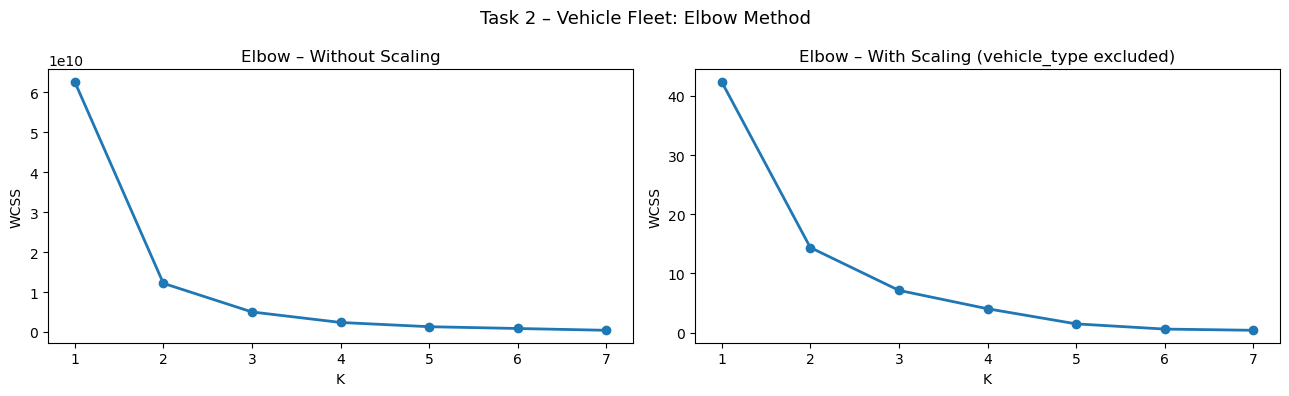

In [47]:
num_feats2 = ['mileage', 'fuel_efficiency', 'maintenance_cost']
X2_raw = df2[num_feats2 + ['vehicle_type_enc']].values

sc2 = StandardScaler()
X2_sc = np.hstack([sc2.fit_transform(df2[num_feats2]),
                   df2[['vehicle_type_enc']].values])

K_range2 = range(1, 8)
wcss2_raw, wcss2_sc = [], []
for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    wcss2_raw.append(km.fit(X2_raw).inertia_)
    wcss2_sc.append(km.fit(X2_sc).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, wcss, title in zip(
    axes, [wcss2_raw, wcss2_sc],
    ['Without Scaling', 'With Scaling (vehicle_type excluded)']
):
    ax.plot(K_range2, wcss, marker='o', linewidth=2)
    ax.set_title(f'Elbow – {title}')
    ax.set_xlabel('K'); ax.set_ylabel('WCSS')

fig.suptitle('Task 2 – Vehicle Fleet: Elbow Method', fontsize=13)
plt.tight_layout(); plt.show()


### 2.3 · Cluster Without Scaling

In [48]:
K2 = 3

km2_raw = KMeans(n_clusters=K2, init='k-means++', random_state=42, n_init=10)
df2['Cluster_NoScale'] = km2_raw.fit_predict(X2_raw)

print(f"=== WITHOUT Scaling (K={K2}) ===")
print(df2[['vehicle_serial_no','vehicle_type','mileage',
           'fuel_efficiency','maintenance_cost','Cluster_NoScale']].to_string(index=False))
print("\nCluster means:")
print(df2.groupby('Cluster_NoScale')[num_feats2].mean().round(1))


=== WITHOUT Scaling (K=3) ===
 vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  Cluster_NoScale
                 5          SUV   150000               15              5000                2
                 3        Sedan   120000               18              4000                0
                 8        Truck   250000               10              7000                1
                 2    Hatchback    80000               22              2000                0
                 4        Sedan   100000               20              3000                0
                 7        Truck   220000               12              6500                2
                 6          SUV   180000               16              5500                2
                10        Truck   300000                8              8000                1
                 1    Hatchback    75000               24              1500                0
                 9          SUV   280000

### 2.4 · Cluster With Scaling

In [49]:
km2_sc = KMeans(n_clusters=K2, init='k-means++', random_state=42, n_init=10)
df2['Cluster_Scaled'] = km2_sc.fit_predict(X2_sc)

print(f"=== WITH Scaling, vehicle_type excluded (K={K2}) ===")
print(df2[['vehicle_serial_no','vehicle_type','mileage',
           'fuel_efficiency','maintenance_cost','Cluster_Scaled']].to_string(index=False))
print("\nCluster means:")
print(df2.groupby('Cluster_Scaled')[num_feats2].mean().round(1))


=== WITH Scaling, vehicle_type excluded (K=3) ===
 vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  Cluster_Scaled
                 5          SUV   150000               15              5000               2
                 3        Sedan   120000               18              4000               2
                 8        Truck   250000               10              7000               1
                 2    Hatchback    80000               22              2000               0
                 4        Sedan   100000               20              3000               2
                 7        Truck   220000               12              6500               1
                 6          SUV   180000               16              5500               2
                10        Truck   300000                8              8000               1
                 1    Hatchback    75000               24              1500               0
                 9          SU

### 2.5 · Visualise & Compare

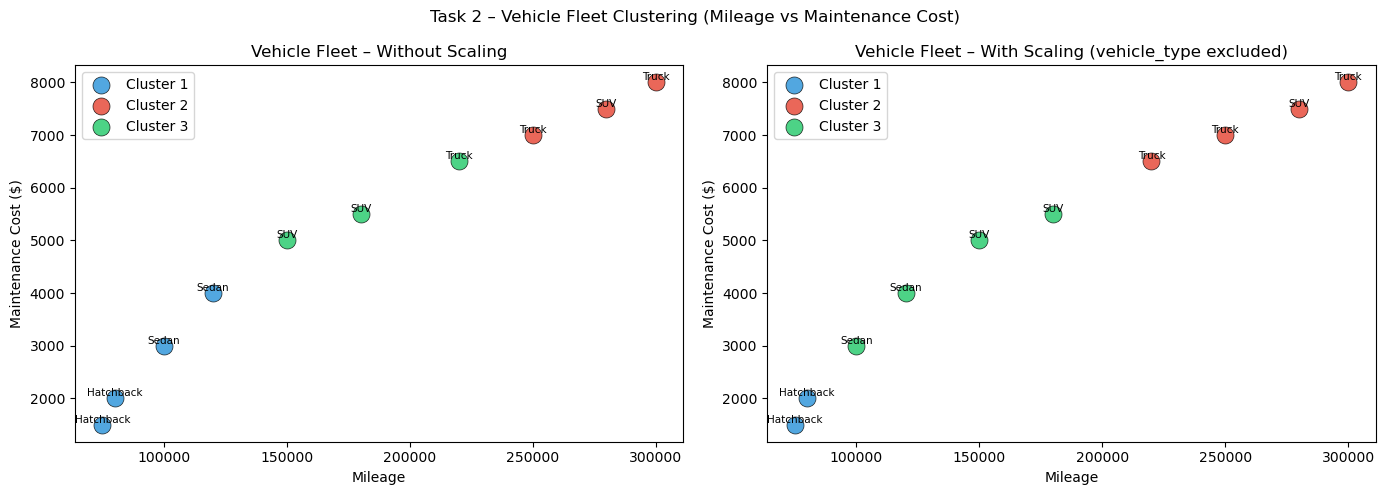

In [50]:
colors3 = ['#3498db','#e74c3c','#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['Cluster_NoScale','Cluster_Scaled'],
    ['Without Scaling','With Scaling (vehicle_type excluded)']
):
    for c in range(K2):
        mask = df2[col] == c
        ax.scatter(df2.loc[mask,'mileage'], df2.loc[mask,'maintenance_cost'],
                   s=150, c=colors3[c], alpha=0.85,
                   edgecolors='k', linewidths=0.5, label=f'Cluster {c+1}')
    for _, row in df2.iterrows():
        ax.annotate(row['vehicle_type'],
                    (row['mileage'], row['maintenance_cost']),
                    fontsize=7.5, ha='center', va='bottom')
    ax.set_xlabel('Mileage'); ax.set_ylabel('Maintenance Cost ($)')
    ax.set_title(f'Vehicle Fleet – {title}'); ax.legend()

fig.suptitle('Task 2 – Vehicle Fleet Clustering (Mileage vs Maintenance Cost)', fontsize=12)
plt.tight_layout(); plt.show()


### 2.6 · Analysis

In [51]:
print("""
WITHOUT Scaling
  mileage (75k-300k) vastly outscales fuel_efficiency (8-24).
  -> Clusters are just mileage bands; fuel efficiency ignored.

WITH Scaling (vehicle_type excluded)
  All numeric features normalised to z-scores -> equal weight.
  Richer segments emerge:
    Low mileage, high efficiency, low cost  -> Hatchbacks / Sedans
    High mileage, low efficiency, high cost -> Trucks
    Mid-range                               -> SUVs / mixed

Conclusion: Scaling essential when feature ranges differ widely.
""")



WITHOUT Scaling
  mileage (75k-300k) vastly outscales fuel_efficiency (8-24).
  -> Clusters are just mileage bands; fuel efficiency ignored.

WITH Scaling (vehicle_type excluded)
  All numeric features normalised to z-scores -> equal weight.
  Richer segments emerge:
    Low mileage, high efficiency, low cost  -> Hatchbacks / Sedans
    High mileage, low efficiency, high cost -> Trucks
    Mid-range                               -> SUVs / mixed

Conclusion: Scaling essential when feature ranges differ widely.



---
## Task 3 – Student Academic Grouping (FAST NUCES Karachi)
Group students into clusters to design targeted support programs.

Features: `GPA`, `study_hours` (weekly average), `attendance_rate` (%).


### 3.1 · Generate Student Dataset

In [52]:
np.random.seed(99)

ga = pd.DataFrame({'GPA': np.random.uniform(3.4,4.0,40),
                   'study_hours': np.random.uniform(18,30,40),
                   'attendance_rate': np.random.uniform(85,100,40)})
gb = pd.DataFrame({'GPA': np.random.uniform(2.5,3.39,45),
                   'study_hours': np.random.uniform(8,17,45),
                   'attendance_rate': np.random.uniform(65,84,45)})
gc = pd.DataFrame({'GPA': np.random.uniform(1.0,2.49,35),
                   'study_hours': np.random.uniform(1,7,35),
                   'attendance_rate': np.random.uniform(30,64,35)})

df3 = pd.concat([ga,gb,gc], ignore_index=True).sample(frac=1, random_state=5).reset_index(drop=True)
df3.insert(0, 'student_id', range(1001, 1001+len(df3)))

print(f"Shape: {df3.shape}")
df3.head(8)


Shape: (120, 4)


,student_id,GPA,study_hours,attendance_rate
0,1001,2.576977,12.586815,77.244922
1,1002,2.654932,15.357232,72.968560
2,1003,3.957327,23.640343,88.009889
3,1004,3.861876,24.592541,95.365448
4,1005,1.097949,3.261460,62.465643
5,1006,3.889685,26.463460,88.844389
6,1007,3.359803,9.709104,72.300511
7,1008,2.959629,16.460923,77.907675


### 3.2 · Feature Scaling

In [53]:
feats3 = ['GPA', 'study_hours', 'attendance_rate']
X3 = df3[feats3].values

sc3 = StandardScaler()
X3_sc = sc3.fit_transform(X3)

pd.DataFrame(X3_sc, columns=[f'{f} (scaled)' for f in feats3]).describe().round(3)


,GPA (scaled),study_hours (scaled),attendance_rate (scaled)
count,120.000,120.000,120.000
mean,-0.000,0.000,-0.000
std,1.004,1.004,1.004
min,-2.248,-1.492,-2.317
25%,-0.762,-0.896,-0.784
50%,0.285,-0.125,0.070
75%,0.783,0.844,0.852
max,1.390,1.820,1.469


### 3.3 · Elbow Method (K = 2 to 6)

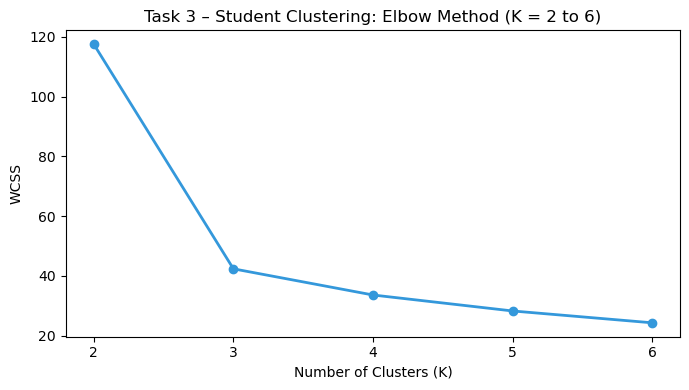

Select the K at the sharpest bend, then set OPTIMAL_K3 below.


In [54]:
K_range3 = range(2, 7)
wcss3 = []
for k in K_range3:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    wcss3.append(km.fit(X3_sc).inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range3, wcss3, marker='o', linewidth=2, color='#3498db')
plt.xticks(list(K_range3))
plt.xlabel('Number of Clusters (K)'); plt.ylabel('WCSS')
plt.title('Task 3 – Student Clustering: Elbow Method (K = 2 to 6)')
plt.tight_layout(); plt.show()
print("Select the K at the sharpest bend, then set OPTIMAL_K3 below.")


### 3.4 · Apply K-Means with Optimal K

In [55]:
OPTIMAL_K3 = 3

km3 = KMeans(n_clusters=OPTIMAL_K3, init='k-means++', random_state=42, n_init=10)
df3['Cluster'] = km3.fit_predict(X3_sc)

print(f"Cluster means (K={OPTIMAL_K3}):")
print(df3.groupby('Cluster')[feats3].mean().round(2))
print(f"\nStudents per cluster:\n{df3['Cluster'].value_counts().sort_index().to_string()}")


Cluster means (K=3):
          GPA  study_hours  attendance_rate
Cluster                                    
0        3.68        24.47            92.20
1        3.00        12.41            74.67
2        1.80         3.86            48.41

Students per cluster:
Cluster
0    40
1    45
2    35


### 3.5 · Scatter Plot (Study Hours vs GPA)

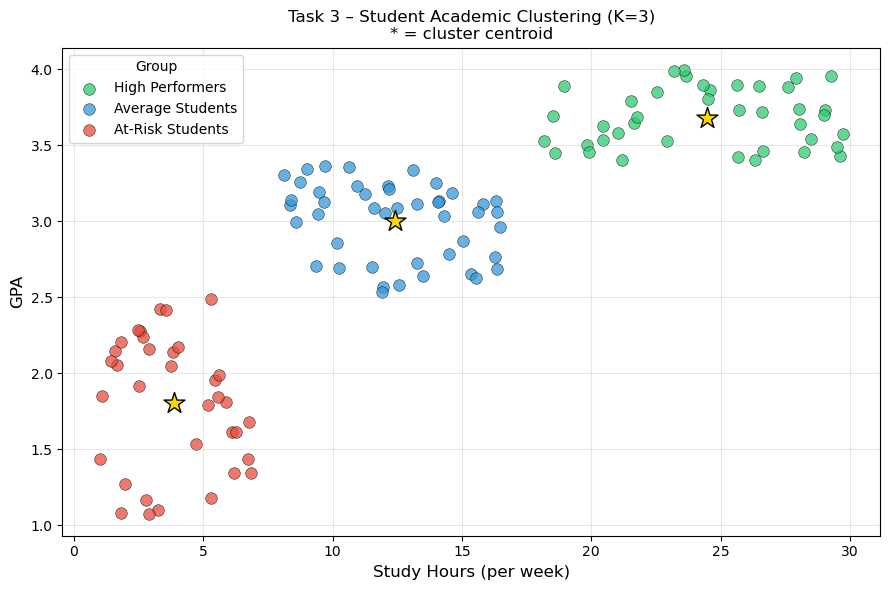

In [56]:
means3   = df3.groupby('Cluster')['GPA'].mean().sort_values(ascending=False)
desc3    = {means3.index[0]: 'High Performers',
            means3.index[1]: 'Average Students',
            means3.index[2]: 'At-Risk Students'}
palette3 = {means3.index[0]: '#2ecc71',
            means3.index[1]: '#3498db',
            means3.index[2]: '#e74c3c'}

centroids_orig = sc3.inverse_transform(km3.cluster_centers_)

plt.figure(figsize=(9, 6))
for c in range(OPTIMAL_K3):
    mask = df3['Cluster'] == c
    plt.scatter(df3.loc[mask,'study_hours'], df3.loc[mask,'GPA'],
                s=70, alpha=0.75, color=palette3[c],
                edgecolors='k', linewidths=0.4, label=desc3.get(c, f'Cluster {c}'))

for c in range(OPTIMAL_K3):
    plt.scatter(centroids_orig[c,1], centroids_orig[c,0],
                s=250, marker='*', c='gold', edgecolors='k', zorder=5)

plt.xlabel('Study Hours (per week)', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.title(f'Task 3 – Student Academic Clustering (K={OPTIMAL_K3})\n* = cluster centroid', fontsize=12)
plt.legend(title='Group', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 3.6 · Final Dataset with Cluster Labels

In [57]:
df3['Group'] = df3['Cluster'].map(desc3)
final3 = df3[['student_id','GPA','study_hours','attendance_rate','Cluster','Group']]
print(final3.sort_values('Cluster').to_string(index=False))


 student_id      GPA  study_hours  attendance_rate  Cluster            Group
       1060 3.458119    26.622077        97.103149        0  High Performers
       1058 3.532946    20.464641        86.599351        0  High Performers
       1032 3.575361    29.717416        92.898795        0  High Performers
       1088 3.692847    18.501102        92.743794        0  High Performers
       1084 3.739370    28.019026        86.583100        0  High Performers
       1082 3.803367    24.505052        93.194030        0  High Performers
       1080 3.884830    27.607898        88.528998        0  High Performers
       1039 3.626463    20.444740        86.551995        0  High Performers
       1040 3.685994    21.751133        89.975552        0  High Performers
       1079 3.939187    27.918702        94.225591        0  High Performers
       1043 3.696488    28.985550        89.483191        0  High Performers
       1044 3.896826    25.639441        99.930473        0  High Performers

### 3.7 · Academic Support Recommendations

In [58]:
print("""
High Performers
  High GPA, high study hours, high attendance.
  -> Advanced electives, research opportunities,
     merit scholarships, peer-tutor roles.

Average Students
  Moderate GPA, moderate engagement.
  -> Regular mentoring, study group formation,
     academic planning workshops.

At-Risk Students
  Low GPA, low study hours, poor attendance.
  -> Immediate intervention: mandatory tutoring,
     attendance alerts to advisor, counselling,
     motivation workshops to address barriers.
""")



High Performers
  High GPA, high study hours, high attendance.
  -> Advanced electives, research opportunities,
     merit scholarships, peer-tutor roles.

Average Students
  Moderate GPA, moderate engagement.
  -> Regular mentoring, study group formation,
     academic planning workshops.

At-Risk Students
  Low GPA, low study hours, poor attendance.
  -> Immediate intervention: mandatory tutoring,
     attendance alerts to advisor, counselling,
     motivation workshops to address barriers.

